# WATER MANAGEMENT REPORT
By ABENEZER SISAY



march 2026


https://www.unicas.it/media/gizfxl2c/unicas_emblem.svg
  ## sewer systems 
A sewer system (or sewerage system) is a wastewater collection and conveyance infrastructure comprising pipes, manholes, pumping stations, and ancillary components, constructed primarily below ground, whose function is to transport domestic sewage, industrial wastewater, and in certain configurations surface runoff (storm water) from urban and peri-urban settlements to wastewater treatment plants or designated discharge locations.

## Stage Discharge Curve
A stage–discharge curve is a rating function that relates the water surface elevation (stage) at a gauging station to the corresponding volumetric flow rate (discharge), typically derived from a series of concurrent measurements of stage and discharge across a range of hydrologic conditions

# Exercise N.2
The student must obtain both in tabular and graphical form the reference stage-discharge curve for a conduit with a circular section having Ks = 70, 80, 90 m1/3/s.
In addition, draw the stage-discharge curve for the section shown below (lengths are in mm), assuming that Ks = 60 m1/3/s and that the bottom slope is 0.005.


## Step 1: Importing Data

The first step in this project is to **load the data** from an Excel file.  
I used **Pandas**, which is a Python module that makes it easy to read and work with Excel files.  

We also import **NumPy**, which is a module that helps with **mathematical calculations**.  

By loading the Excel file, we can get the water depths and other input values needed for the calculations in Python.

In [4]:
import pandas as pd

In [5]:
import pandas as pd

df = pd.read_excel(r"C:\Users\Abeni\water managmnt python\exercise2.xlsx")

df.head()

,FR,h,Ø,A,p,R,v(70),Q(70),v(80),Q(80),v(90),Q(90)
0,0.01,0.01,0.400670,0.001329,0.200335,0.006636,2.471808,0.003286,2.824924,0.003755,3.178039,0.004225
1,0.02,0.02,0.567588,0.003749,0.283794,0.013209,3.911436,0.014662,4.470213,0.016757,5.028989,0.018851
2,0.03,0.03,0.696332,0.006866,0.348166,0.019719,5.109233,0.035077,5.839123,0.040089,6.569014,0.045100
3,0.04,0.04,0.805432,0.010538,0.402716,0.026167,6.169697,0.065015,7.051082,0.074302,7.932467,0.083590
4,0.05,0.05,0.902054,0.014681,0.451027,0.032551,7.136353,0.104772,8.155831,0.119740,9.175310,0.134707


When we use `data.head()` in Python, it shows only the **first 5 rows** of the Excel file by default.  
This is useful to quickly check the data without printing the whole table.  

In my Excel file, there are **more columns**.  

If we want to see more rows, we can put a number inside the brackets.  
For example, i think we have 50 rows`data.head(50)` will display the **first 50 rows** from the Excel file.  

This helps us check that all the input data is correctly loaded before doing calculations.

In [6]:
df.columns

Index(['FR', 'h', 'Ø', 'A', 'p', 'R', 'v(70)', 'Q(70)', 'v(80)', 'Q(80)',
       'v(90)', 'Q(90)'],
      dtype='object')

When we load the Excel file using Pandas, Python automatically reads the **column names** from the Excel file.  

This means we do **not need to manually define the columns** in Python.  
For example, if the Excel file has around 12 columns, Pandas will automatically assign the column names from the first row of the Excel file.  

We can see the column names using:

```python
data.columns

## Importing Libraries and Defining Parameters

After loading the Excel data, the next step is to import another library called **Matplotlib**.  
Matplotlib is a Python library that helps us **create graphs and plots**.

In this project, we use Matplotlib to **draw the final plot**, which shows the relationship between the **flow rate (Q)** and the **filling ratio (FR = h/D)**.

After importing the libraries, we define the **main parameters** used in the calculations.  
These parameters include:

- **D** – the pipe diameter  
- **S** – the pipe slope  
- **ks** – the roughness coefficient  

These values are important because they are used in the formulas to calculate the **flow properties of the circular pipe**.

,h (m),FR (h/D),φ (deg),Area (m²),Perimeter (m),Hydraulic Radius (m),Flow Rate Q (m³/s)
0,0.100000,0.100000,73.739795,0.040875,0.643501,0.063520,0.455512
1,0.118367,0.118367,80.494176,0.052327,0.702444,0.074493,0.648494
2,0.136735,0.136735,86.807348,0.064578,0.757537,0.085248,0.875601
3,0.155102,0.155102,92.772088,0.077544,0.809589,0.095781,1.136313
4,0.173469,0.173469,98.454391,0.091153,0.859177,0.106093,1.429961
5,0.191837,0.191837,103.903257,0.105344,0.906727,0.116180,1.755750
6,0.210204,0.210204,109.156321,0.120064,0.952569,0.126042,2.112779
7,0.228571,0.228571,114.243301,0.135264,0.996961,0.135676,2.500054
8,0.246939,0.246939,119.188217,0.150901,1.040113,0.145081,2.916502
9,0.265306,0.265306,124.010877,0.166933,1.082199,0.154254,3.360973


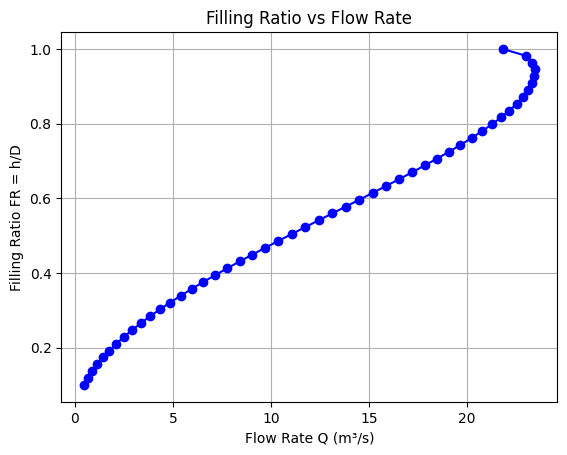

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Pipe properties
D = 1.0
S = 1.0
ks = 70

# Correct central angle function
def central_angle(h, D):
    return 2 * np.arccos(1 - 2*h/D)

def area_flow(h, D):
    phi = central_angle(h, D)
    return (D**2 / 8) * (phi - np.sin(phi))

def wetted_perimeter(h, D):
    r = D / 2
    phi = central_angle(h, D)
    return r * phi

def hydraulic_radius(h, D):
    A = area_flow(h, D)
    P = wetted_perimeter(h, D)
    return A / P

def flow_rate(h, D, Sf, ks):
    A = area_flow(h, D)
    R = hydraulic_radius(h, D)
    return ks * A * R**(2/3) * Sf**0.5

# Water depths
h_values = np.linspace(0.1, D, 50)  # finer points for smooth curve

# Compute properties and falling ratio
results = []
flow_rates = []
FR_values = []

for h in h_values:
    Q = flow_rate(h, D, S, ks)
    FR = h / D
    flow_rates.append(Q)
    FR_values.append(FR)
    phi = central_angle(h, D)
    A = area_flow(h, D)
    P = wetted_perimeter(h, D)
    R = hydraulic_radius(h, D)
    results.append([h, FR, np.degrees(phi), A, P, R, Q])

# Create table
df = pd.DataFrame(results, columns=['h (m)', 'FR (h/D)', 'φ (deg)', 'Area (m²)', 'Perimeter (m)', 'Hydraulic Radius (m)', 'Flow Rate Q (m³/s)'])
display(df)

# Plot Falling Ratio vs Flow Rate
plt.plot(flow_rates, FR_values, marker='o', color='blue')
plt.xlabel('Flow Rate Q (m³/s)')
plt.ylabel('Filling Ratio FR = h/D')
plt.title('Filling Ratio vs Flow Rate')
plt.grid(True)
plt.show()

Finally, we plot the results to create the stage–discharge curve. In this case, I used  𝑘s=70
Although values such as 80 and 90 are also available, I selected 70 for this as example. The graph shows the relationship between the flow rate (Q) and the water stage (h). Each value from the columns is calculated and then used to draw the final plot.

                                                         GRAZIE MILE 